# Full core STORM tutorial with dummy components

This notebook walks through the implemented STORM core with dependency-free components: data references, a preparation pipeline, registered dummy models, classic metrics, persisted artifacts, and a simple visualization.

## 1. Local imports

The cell below makes the source tree importable when the notebook is launched from the repository root or from `examples/notebooks`.

In [5]:
from pathlib import Path
import sys
from tempfile import TemporaryDirectory

from IPython.display import SVG, display


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "src" / "storm").is_dir():
            return candidate
    raise RuntimeError("Could not find the STORM project root.")


PROJECT_ROOT = find_project_root(Path.cwd())
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

PROJECT_ROOT

PosixPath('/home/munhof/Escritorio/proyectos/tesis/STORM-System-for-Traceable-Orchestration-Reuse-and-Modeling')

In [6]:
from storm import (
    DataRef,
    Dataset,
    FileArtifactStore,
    MetricRegistry,
    ModelRegistry,
    PipelineDataLoader,
    PipelineRunner,
    PipelineSpec,
    RunSpec,
    StepRegistry,
    StepSpec,
    Study,
    StudySpec,
    VisualizationManager,
    VisualizationRegistry,
    VisualizationRequest,
    VisualizationSpec,
)
from storm.metrics.classic import register_classic_metrics
from storm.testing import register_dummy_models

## 2. Data loader and preparation pipeline

`DataRef` is the serializable identity of the dataset. The loader resolves it into runtime data, and `PipelineDataLoader` applies traceable preparation steps before the study sees the final `Dataset`.

In [7]:
def load_numbers(reference: DataRef) -> Dataset:
    return Dataset(
        inputs=[0, 1, 2, 3],
        targets=[1, 3, 5, 7],
        metadata={"source": reference.identifier},
    )


steps = StepRegistry()
steps.discover("storm.testing")

pipeline_spec = PipelineSpec(
    pipeline_id="numeric-demo",
    steps=(StepSpec("scale", {"factor": 2}),),
)
pipeline = PipelineRunner.from_spec(pipeline_spec, registry=steps)
data_loader = PipelineDataLoader(loader=load_numbers, runner=pipeline)

prepared = data_loader(DataRef(identifier="numbers", fingerprint="sha256:demo-numbers"))
prepared.inputs, prepared.targets, prepared.metadata["pipeline_id"]

([0.0, 2.0, 4.0, 6.0], [1, 3, 5, 7], 'numeric-demo')

## 3. Model and metric registries

Registries keep runtime implementations separate from serializable study specs. Here we register the built-in dummy model catalog and classic scalar metrics.

In [8]:
models = ModelRegistry()
register_dummy_models(models)

metrics = MetricRegistry()
register_classic_metrics(metrics)

spec = StudySpec(
    study_id="full-core-notebook-demo",
    data=DataRef(identifier="numbers", fingerprint="sha256:demo-numbers"),
    runs=(
        RunSpec("constant-zero", "constant", {"value": 0}, seed=7),
        RunSpec("identity", "identity", {}, seed=7),
        RunSpec("mean-target", "mean_regressor", {}, seed=7),
    ),
    metrics=("mae", "mse"),
)

spec.study_id

'full-core-notebook-demo'

## 4. Run the study and inspect traceable results

`Study.run()` fits each configured run, evaluates metrics, and writes model, output, and run artifacts with lineage metadata.

In [9]:
workspace = TemporaryDirectory(prefix="storm-notebook-")
artifact_root = Path(workspace.name) / "artifacts"

study = Study(
    spec,
    data_loader=data_loader,
    models=models,
    metrics=metrics,
    artifacts=FileArtifactStore(artifact_root),
)
results = study.run()

rows = [
    {
        "run_id": result.run_id,
        "model_type": result.record.model_type,
        **result.metrics,
        "execution_id": result.record.execution_id,
    }
    for result in results
]
rows

[{'run_id': 'constant-zero',
  'model_type': 'constant',
  'mae': 4.0,
  'mse': 21.0,
  'execution_id': 'execution-40e86b12cdcf4d1c9ccada77d40ddba1'},
 {'run_id': 'identity',
  'model_type': 'identity',
  'mae': 1.0,
  'mse': 1.0,
  'execution_id': 'execution-7c7d83644112483e8661bb9c1b8f8b0c'},
 {'run_id': 'mean-target',
  'model_type': 'mean_regressor',
  'mae': 2.0,
  'mse': 5.0,
  'execution_id': 'execution-17e9cacdee5a4ba78779ad2d73ead352'}]

In [10]:
best = results.select("mse", maximize=False)
best_output = best.load_output()
best_model = best.load_model()

best.run_id, best.metrics, best_output.predictions, type(best_model).__name__

('identity', {'mae': 1.0, 'mse': 1.0}, [0.0, 2.0, 4.0, 6.0], 'IdentityModel')

## 5. Render a visualization from the same result

Visualizations are registered and rendered through the same plugin-style pattern as models and steps.

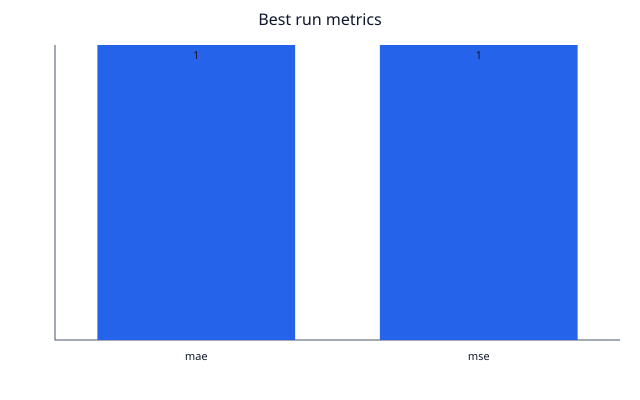

'image/svg+xml'

In [11]:
visualizations = VisualizationRegistry()
visualizations.discover("storm.visualization.classic")

chart = VisualizationManager(visualizations).render(
    VisualizationSpec("metric_bar", {"title": "Best run metrics"}),
    VisualizationRequest(metrics=best.record.metrics),
)

display(SVG(chart.content))
chart.media_type

## 6. Clean up temporary artifacts

The tutorial used a temporary artifact directory. Remove it when you are done inspecting the files.

In [12]:
workspace.cleanup()